In [ ]:
import pandas as pd
import os

In [2]:


# 1. Read the Excel file
df = pd.read_excel("140826-ds-PLA.xlsx", sheet_name=0)

# 2. Save it as a CSV
df.to_csv("140826-ds-PLA.csv", index=False)

# 3. Now you can use standard CSV operations on it
df_csv = pd.read_csv("140826-ds-PLA.csv")

In [ ]:


# 1. Load the CSV file
df = pd.read_csv("260821-ds-PLA.csv")

# Extract rows 12 to 22 (indices 11 to 21) and columns 3 onwards, converted to int
integers = df.iloc[10:, 2:].astype(int)

"""
# 2. Extract row 22 (which is the last row / index -1 of our `integers` subset)
subtrahend_row = integers.iloc[-1]

# 3. Subtract row 22 from rows 12 to 21 (all rows in `integers` except the last one)
integers_data = integers.iloc[:-1] - subtrahend_row
"""

integers_data = integers.iloc[:]

# 4. Save the result back to a new CSV file
integers_data.to_csv("data_analysis/260821-ds-PLA-edited.csv", index=False)


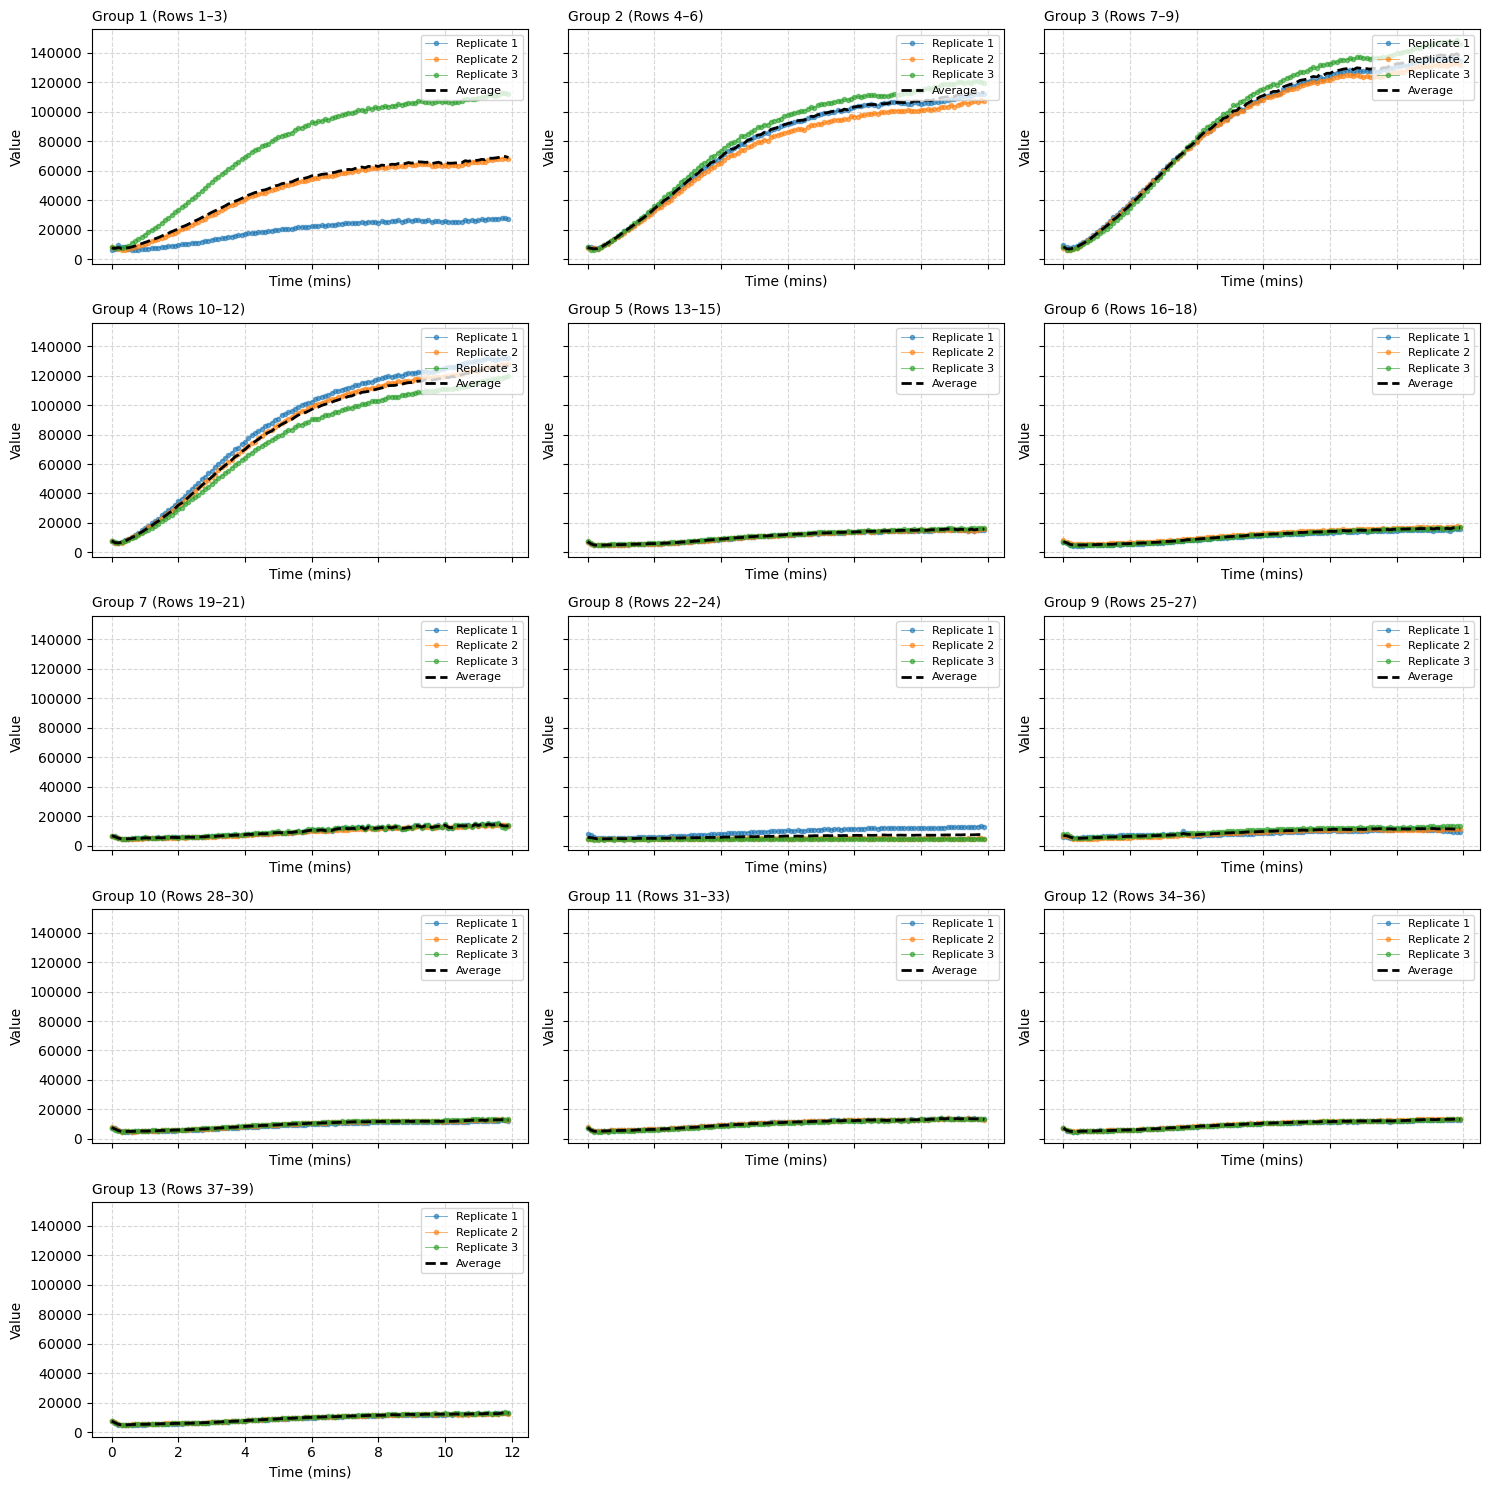

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the edited dataset
edited_df = pd.read_csv("data_analysis/260818-ds-PLA-edited.csv")

# 2. Calculate the X-axis values
num_columns = edited_df.shape[1]
x_values = np.arange(num_columns) / 10  # Time values

# 3. Determine the number of subplots and grid layout (3 columns)
replicates_per_group = 3
num_rows = len(edited_df)
num_subplots = int(np.ceil(num_rows / replicates_per_group))

n_cols = 3
n_rows = int(np.ceil(num_subplots / n_cols))

# Create 3-column grid layout
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows), sharex=True, sharey=True)

# Flatten axes array for simple 1D indexing
axes_flat = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

# 4. Loop through groups of 3 rows
for subplot_idx in range(num_subplots):
    ax = axes_flat[subplot_idx]
    
    # Extract the 3 replicate rows for this subplot
    start_row = subplot_idx * replicates_per_group
    end_row = min(start_row + replicates_per_group, num_rows)
    group_df = edited_df.iloc[start_row:end_row]
    
    # Plot individual replicate points with small markers
    for idx, (row_label, row_data) in enumerate(group_df.iterrows()):
        ax.plot(
            x_values, 
            row_data.values, 
            marker='o', 
            markersize=3, 
            linewidth=0.7, 
            alpha=0.6, 
            label=f"Replicate {idx + 1}"
        )
    
    # Calculate and plot the average across the 3 replicates
    avg_data = group_df.mean(axis=0)
    ax.plot(
        x_values, 
        avg_data.values, 
        linestyle='--', 
        color='black', 
        linewidth=2, 
        label="Average"
    )
    
    # Formatting
    ax.set_title(f"Group {subplot_idx + 1} (Rows {start_row + 1}–{end_row})", fontsize=10, loc='left')
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right", fontsize=8)

# Set common labels on visible axes
for ax in axes_flat[:num_subplots]:
    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("Value")

# Hide any unused subplots if num_subplots isn't a multiple of 3
for i in range(num_subplots, len(axes_flat)):
    fig.delaxes(axes_flat[i])

plt.tight_layout()
# Save as SVG if needed
# plt.savefig("data_analysis/030826-ds-PLA-plots.svg", format="svg", bbox_inches="tight")
plt.show()

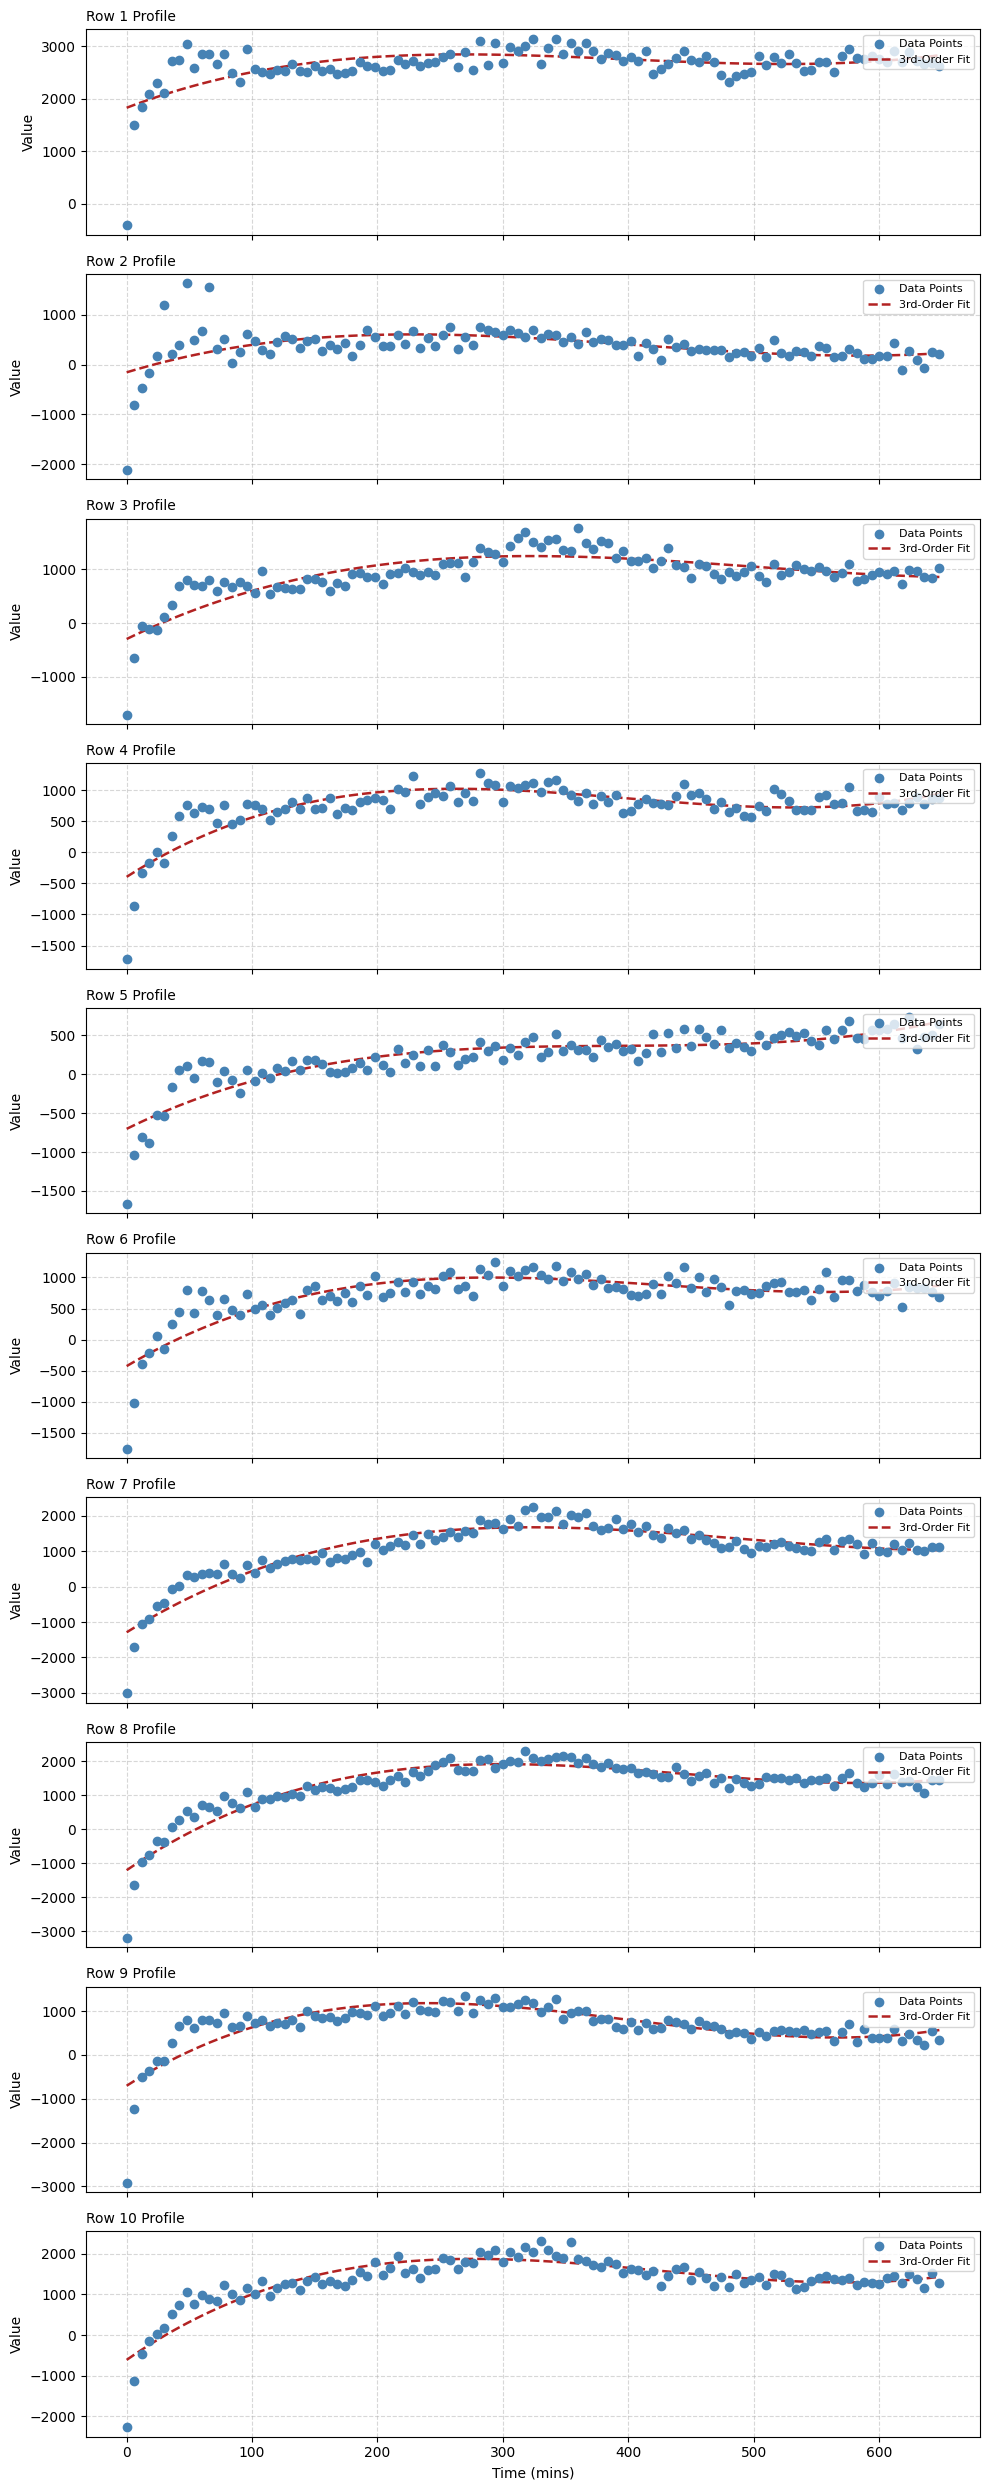

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data and setup X-axis
edited_df = pd.read_csv("../270726-ds-PLA-edited.csv")
x_values = np.arange(edited_df.shape[1]) * 6

# Plot each row with a 3rd-order polynomial fit
fig, axes = plt.subplots(len(edited_df), 1, figsize=(10, 2.5 * len(edited_df)), sharex=True)
axes = np.atleast_1d(axes)

for idx, (row_label, row_data) in enumerate(edited_df.iterrows()):
    ax = axes[idx]
    y_values = row_data.values
    
    # 3rd-degree polynomial fit: y = ax^3 + bx^2 + cx + d
    coeffs = np.polyfit(x_values, y_values, 3)
    fit_line = np.polyval(coeffs, x_values)
    
    # Plot
    ax.scatter(x_values, y_values, color='steelblue', label='Data Points', zorder=3)
    ax.plot(x_values, fit_line, color='firebrick', linestyle='--', linewidth=1.8, label='3rd-Order Fit')
    
    ax.set_ylabel("Value")
    ax.set_title(f"Row {idx + 1} Profile", fontsize=10, loc='left')
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

axes[-1].set_xlabel("Time (mins)")
plt.tight_layout()
plt.savefig("../270726-ds-PLA-3rd_order_plots.svg", format="svg", bbox_inches="tight")
plt.show()

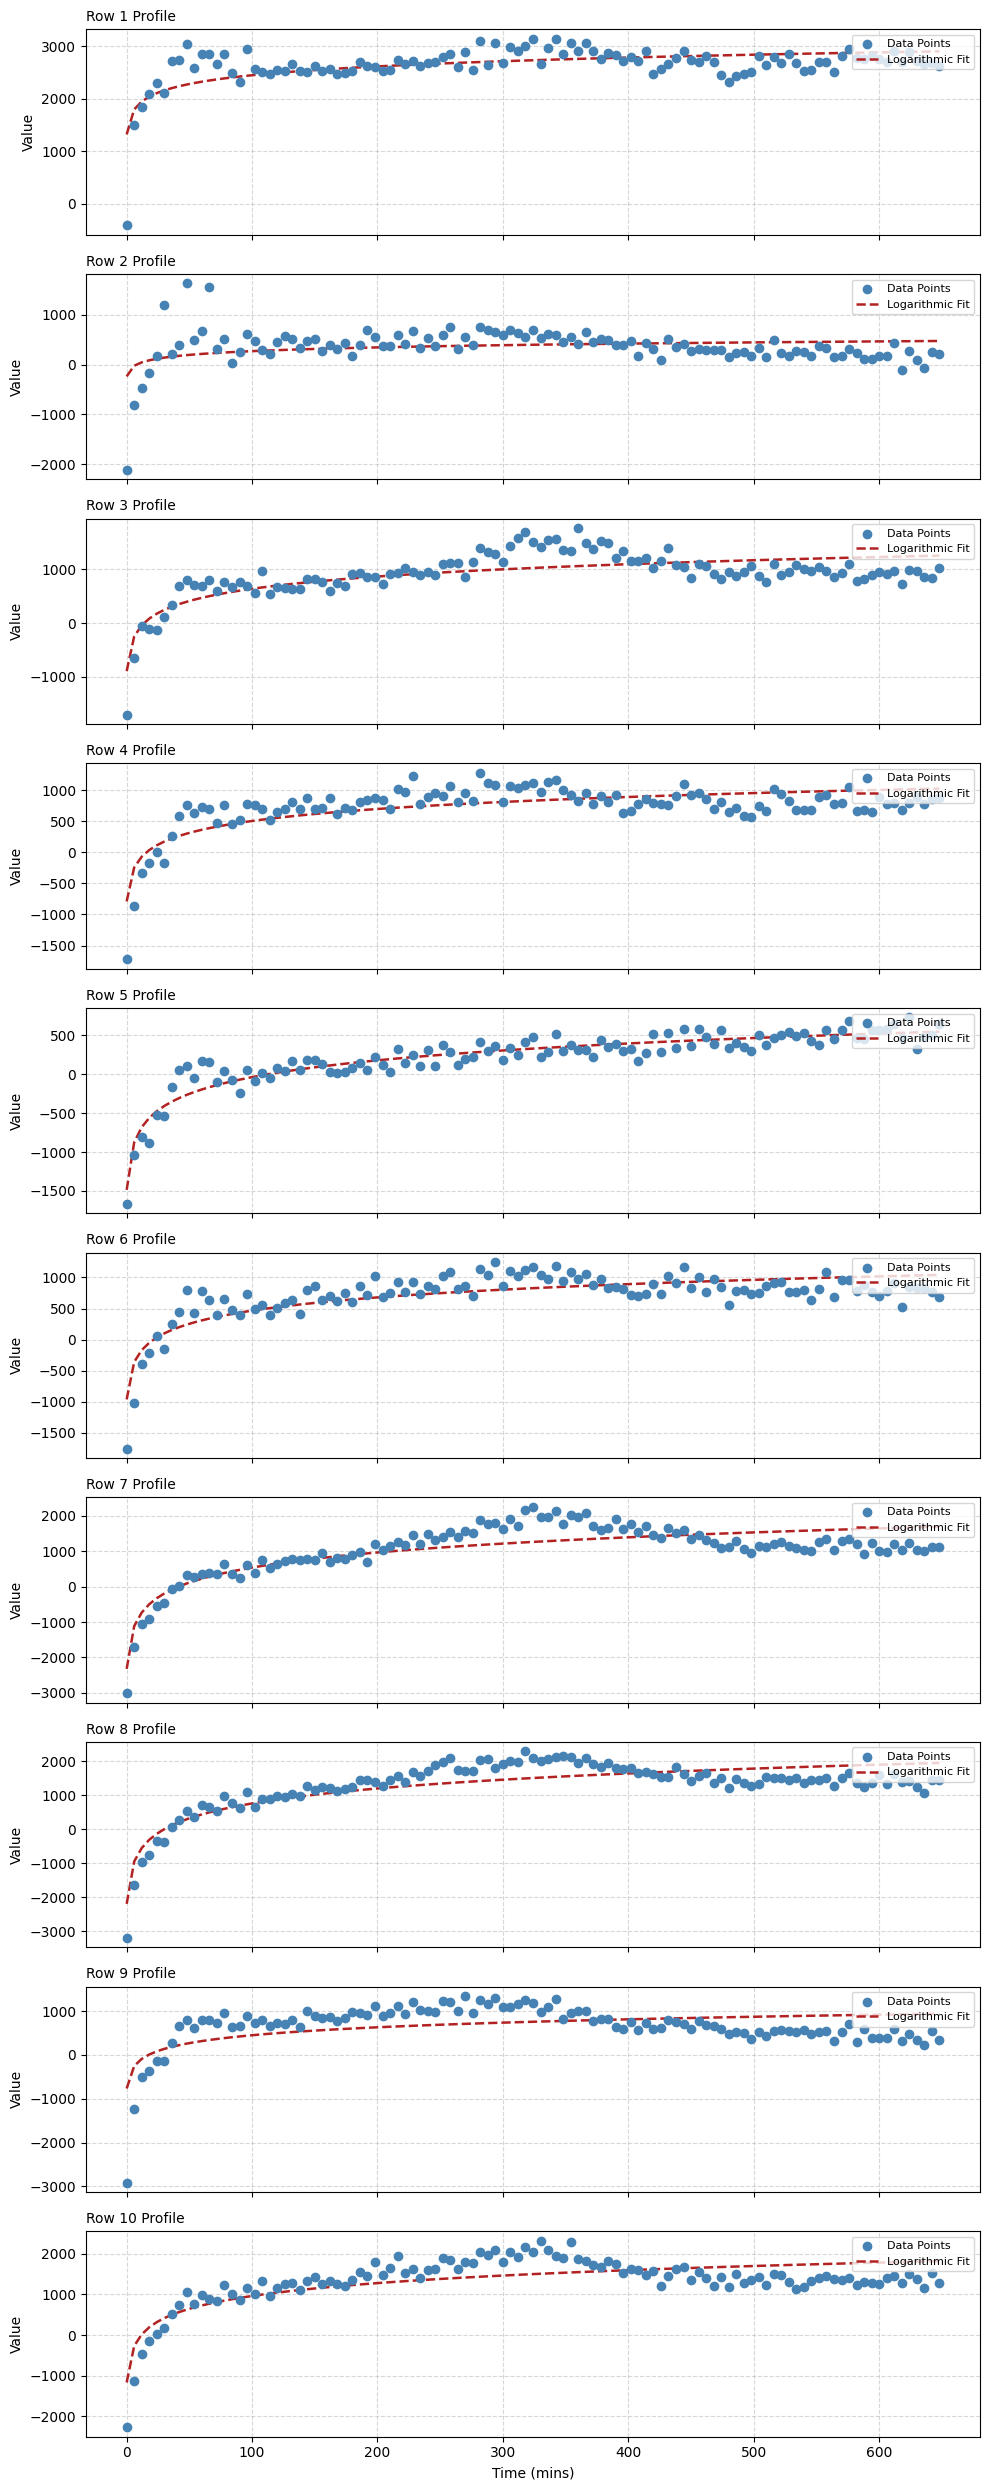

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data and setup X-axis
edited_df = pd.read_csv("../270726-ds-PLA-edited.csv")
x_values = np.arange(edited_df.shape[1]) * 6

# Plot each row with a Logarithmic fit: y = a + b * ln(x + 1)
fig, axes = plt.subplots(len(edited_df), 1, figsize=(10, 2.5 * len(edited_df)), sharex=True)
axes = np.atleast_1d(axes)

for idx, (row_label, row_data) in enumerate(edited_df.iterrows()):
    ax = axes[idx]
    y_values = row_data.values
    
    # Fit linear regression to log(x + 1)
    b, a = np.polyfit(np.log(x_values + 1), y_values, 1)
    fit_line = a + b * np.log(x_values + 1)
    
    # Plot
    ax.scatter(x_values, y_values, color='steelblue', label='Data Points', zorder=3)
    ax.plot(x_values, fit_line, color='firebrick', linestyle='--', linewidth=1.8, label='Logarithmic Fit')
    
    ax.set_ylabel("Value")
    ax.set_title(f"Row {idx + 1} Profile", fontsize=10, loc='left')
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

axes[-1].set_xlabel("Time (mins)")
plt.tight_layout()
plt.savefig("../270726-ds-PLA-logarithmic_plots.svg", format="svg", bbox_inches="tight")
plt.show()

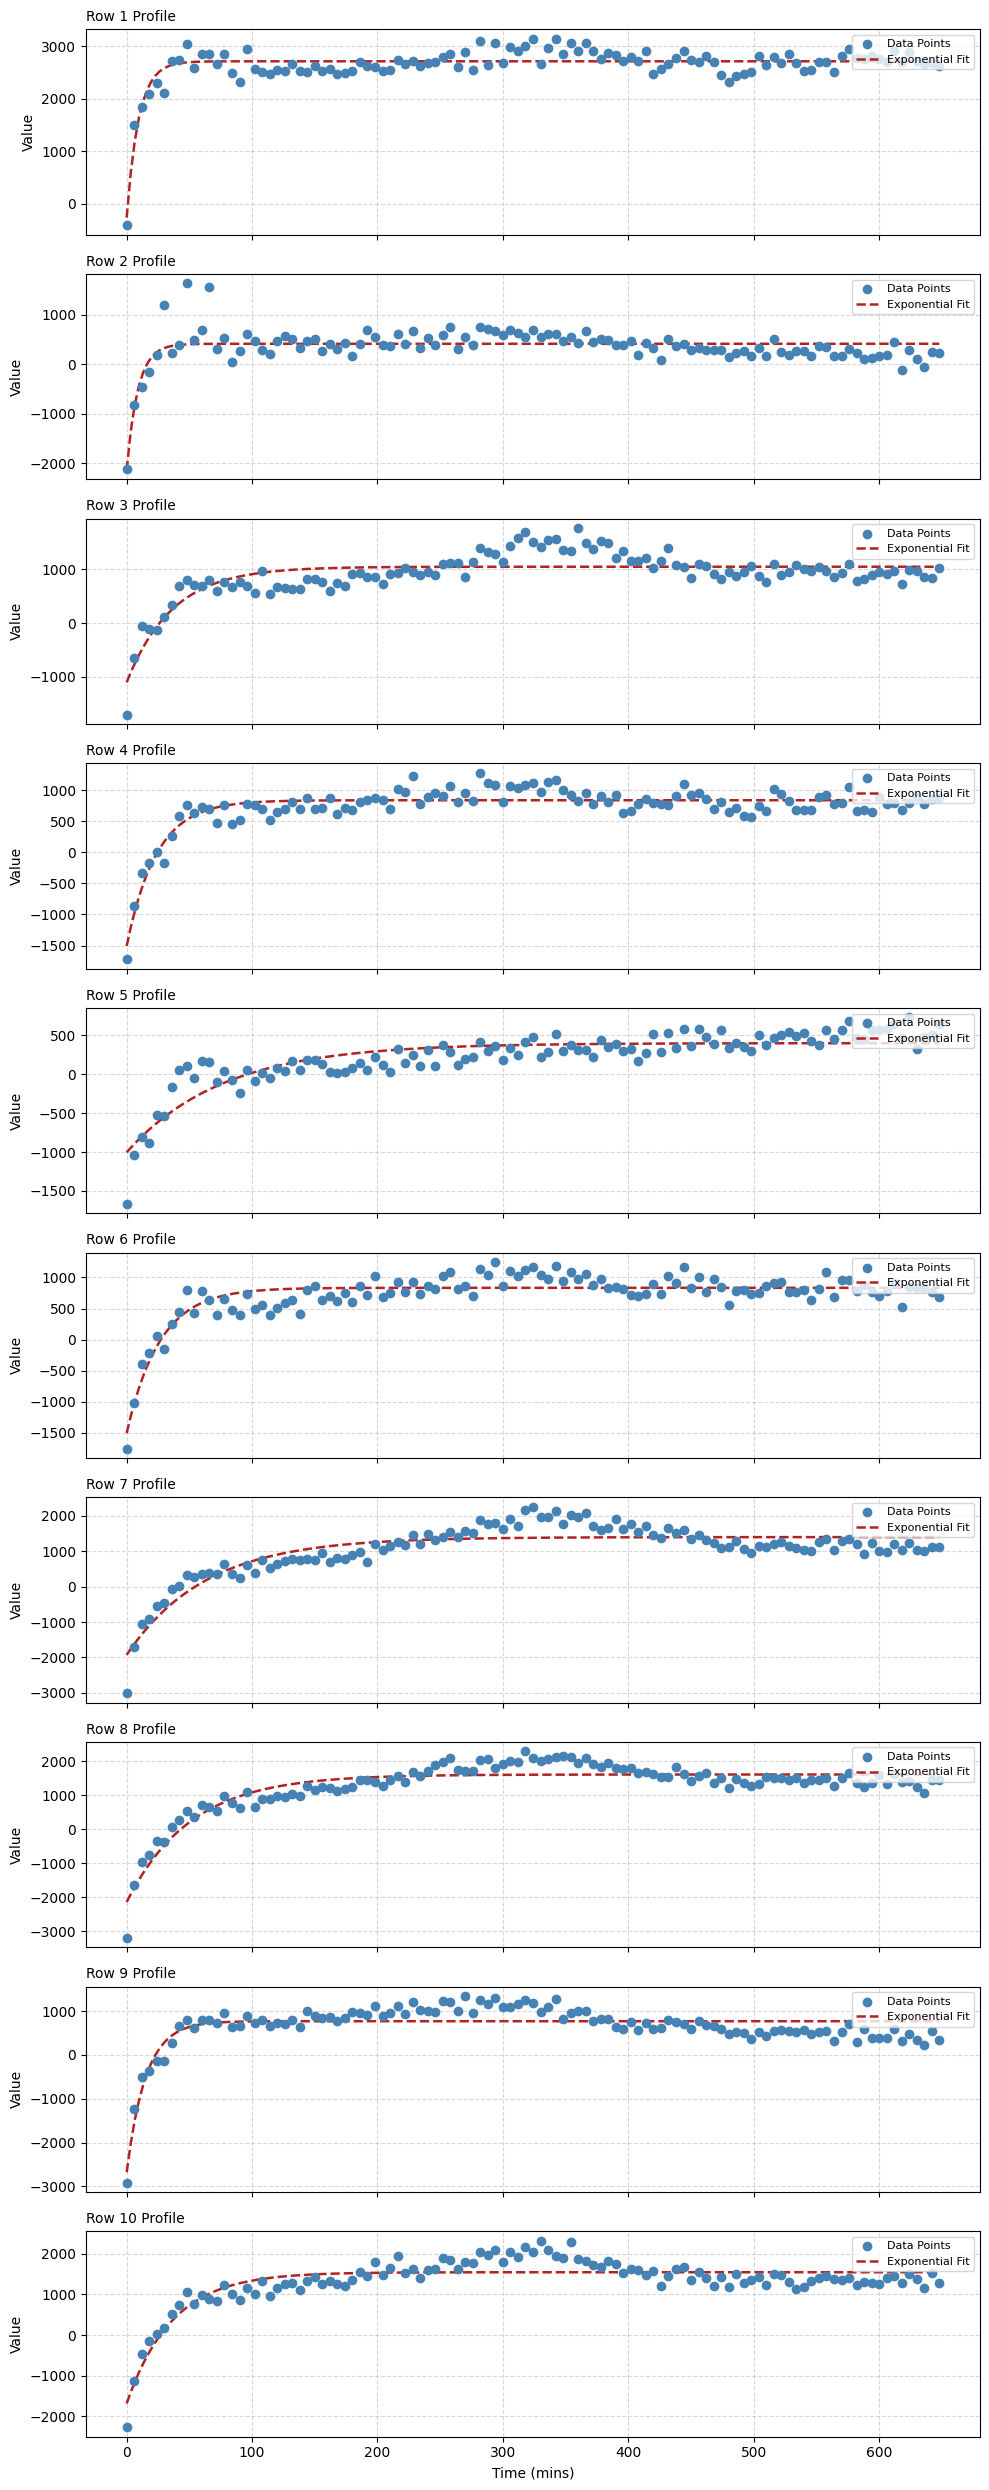

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

edited_df = pd.read_csv("../270726-ds-PLA-edited.csv")
x_values = np.arange(edited_df.shape[1]) * 6.0
x_dense = np.linspace(x_values.min(), x_values.max(), 200) # Smooth curve line

def exp_func(x, a, b, c):
    return a * (1 - np.exp(-b * x)) + c

fig, axes = plt.subplots(len(edited_df), 1, figsize=(10, 2.5 * len(edited_df)), sharex=True)
axes = np.atleast_1d(axes)

for idx, (row_label, row_data) in enumerate(edited_df.iterrows()):
    ax = axes[idx]
    y_values = row_data.values.astype(float)
    
    try:
        # Initial guesses: [amplitude, rate, offset]
        p0 = [y_values.max() - y_values.min(), 0.01, y_values[0]]
        popt, _ = curve_fit(exp_func, x_values, y_values, p0=p0, maxfev=5000)
        fit_line = exp_func(x_dense, *popt)
        label_text = 'Exponential Fit'
    except Exception:  # Fallback if curve doesn't converge
        fit_line = np.polyval(np.polyfit(x_values, y_values, 1), x_dense)
        label_text = 'Linear Fallback'

    ax.scatter(x_values, y_values, color='steelblue', label='Data Points', zorder=3)
    ax.plot(x_dense, fit_line, color='firebrick', linestyle='--', linewidth=1.8, label=label_text)
    
    ax.set_ylabel("Value")
    ax.set_title(f"Row {idx + 1} Profile", fontsize=10, loc='left')
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

axes[-1].set_xlabel("Time (mins)")
plt.tight_layout()
plt.savefig("../270726-ds-PLA-exponential_plots.svg", format="svg", bbox_inches="tight")
plt.show()

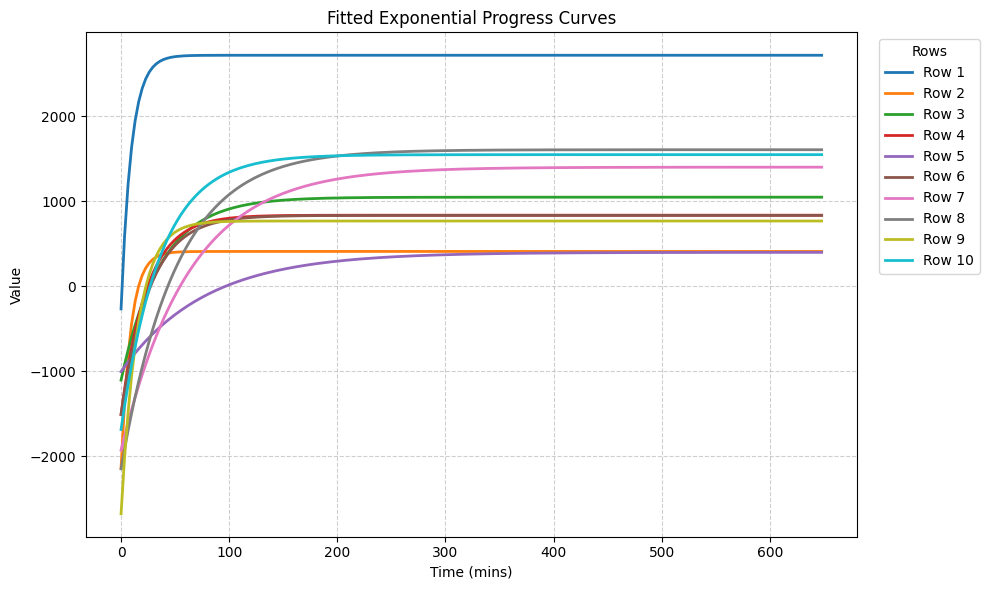

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Load data and setup X-axis
edited_df = pd.read_csv("../270726-ds-PLA-edited.csv")
x_values = np.arange(edited_df.shape[1]) * 6.0
x_dense = np.linspace(x_values.min(), x_values.max(), 200) # Dense X for smooth curves

def exp_func(x, a, b, c):
    return a * (1 - np.exp(-b * x)) + c

# 2. Setup a single plot figure
plt.figure(figsize=(10, 6))

# Use a colormap to automatically assign distinct colors to each row
colors = plt.cm.tab10(np.linspace(0, 1, len(edited_df)))

# 3. Fit and plot each row on the SAME axes
for idx, (row_label, row_data) in enumerate(edited_df.iterrows()):
    y_values = row_data.values.astype(float)
    
    try:
        p0 = [y_values.max() - y_values.min(), 0.01, y_values[0]]
        popt, _ = curve_fit(exp_func, x_values, y_values, p0=p0, maxfev=5000)
        fit_line = exp_func(x_dense, *popt)
    except Exception:
        # Fallback to linear if curve fitting fails
        fit_line = np.polyval(np.polyfit(x_values, y_values, 1), x_dense)

    # Plot ONLY the fitted curve (no scatter points)
    plt.plot(
        x_dense, 
        fit_line, 
        linewidth=2, 
        color=colors[idx], 
        label=f"Row {idx + 1}"
    )

# 4. Styling and Legend
plt.xlabel("Time (mins)")
plt.ylabel("Value")
plt.title("Fitted Exponential Progress Curves")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Rows", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

# Save combined SVG plot before showing
plt.savefig("../270726-ds-PLA-combined_fitted.svg", format="svg", bbox_inches="tight")
plt.show()

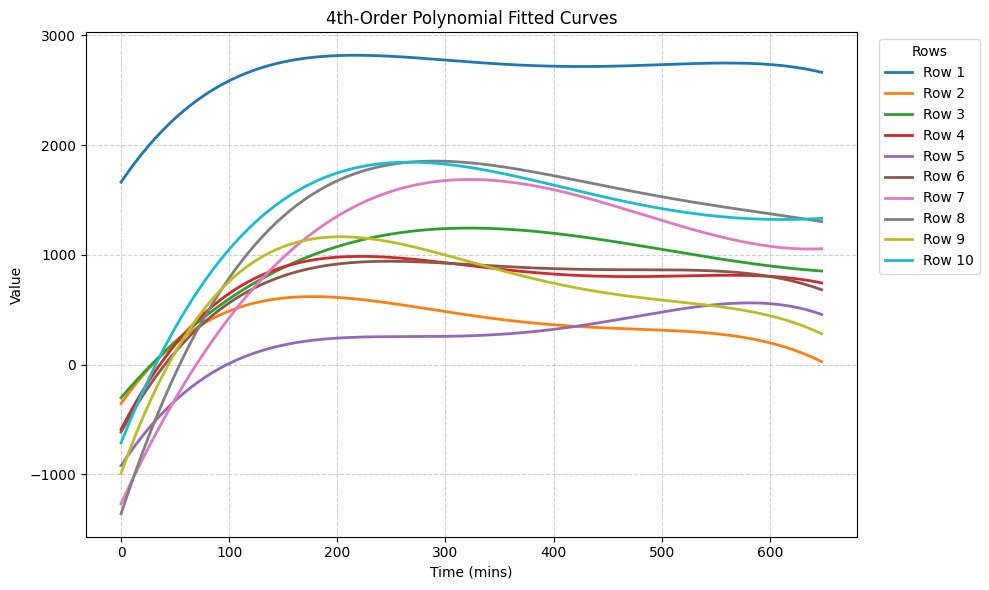

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data and setup X-axis
edited_df = pd.read_csv("../270726-ds-PLA-edited.csv")
x_values = np.arange(edited_df.shape[1]) * 6.0
x_dense = np.linspace(x_values.min(), x_values.max(), 200)  # Dense X for smooth curves

# 2. Setup a single plot figure
plt.figure(figsize=(10, 6))

# Generate distinct colors for each row
colors = plt.cm.tab10(np.linspace(0, 1, len(edited_df)))

# 3. Fit 4th-order polynomial and plot each curve
for idx, (row_label, row_data) in enumerate(edited_df.iterrows()):
    y_values = row_data.values.astype(float)
    
    # 4th-degree polynomial fit
    coeffs = np.polyfit(x_values, y_values, 4)
    fit_line = np.polyval(coeffs, x_dense)

    # Plot ONLY the fitted curve
    plt.plot(
        x_dense, 
        fit_line, 
        linewidth=2, 
        color=colors[idx], 
        label=f"Row {idx + 1}"
    )

# 4. Styling and Legend
plt.xlabel("Time (mins)")
plt.ylabel("Value")
plt.title("4th-Order Polynomial Fitted Curves")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Rows", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

# Save combined SVG plot before showing
plt.savefig("../270726-ds-PLA-combined_4th_order.svg", format="svg", bbox_inches="tight")
plt.show()